# Сегментация клиентов интернет-магазина

## 1. Цель проекта

Выявление скрытых групп клиентов онлайн-магазина на основе транзакционного поведения, оценка качества разбиения и содержательная интерпретация полученных сегментов для повышения эффективности маркетинговых кампаний.

### Бизнес-контекст

Онлайн-магазин уникальных подарков работает без физических точек продаж (сфера e-commerce). Значительную долю клиентов составляют оптовые покупатели. Маркетинговые кампании проводятся для всех клиентов без учёта различий в поведении, что приводит к неэффективному расходованию бюджета.

### Зачем нужна сегментация

- Выявить группы клиентов, не очевидные при поверхностном анализе: оптовики, разовые покупатели дорогих товаров, чувствительные к скидкам.
- Обнаружить атипичное поведение: клиенты с аномально высокой долей возвратов или нестандартной структурой заказов.
- Перейти от интуитивных решений к подходу, основанному на данных, при планировании акций.
- Создать основу для персонализации маркетинговых кампаний: кому отправлять промокоды, кого удерживать, кому предлагать новые категории.

### Задача

Провести сегментацию клиентов на основе RFM-метрик (Recency, Frequency, Monetary) и дополнительных признаков транзакционного поведения. Для каждого сегмента сформировать портрет и дать рекомендации по маркетинговой стратегии. Проект демонстрирует полный ML-пайплайн: предобработка, RFM-инжиниринг, подбор числа кластеров, обучение моделей кластеризации и бизнес-интерпретация результатов.

## 2. Описание датасета

В качестве источника данных выбран датасет "Online Retail II UCI". Ссылка: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci. 

Это реальный набор транзакционных данных интернет-магазина, базирующегося в Великобритании. Магазин специализируется на уникальных подарках «на все случаи жизни». 
Данные охватывают период с 01.12.2009 по 09.12.2011 (2 года).  
Каждая строка — это одна позиция в одной транзакции. Если в транзакции 5 разных товаров, она займет 5 строк с одинаковым InvoiceNo.

Размер:  
Объектов (строк): 1,067,371
Признаков (столбцов): 8

#### Описание признаков

| Признак | Тип | Описание |
|---|---|---|
| InvoiceNo | Категориальный | Номер транзакции. Если начинается с 'C' — отмена |
| StockCode | Категориальный | Уникальный код товара |
| Description | Текстовый | Название (описание) товара (в кластеризации не используется) |
| Quantity | Числовой | Количество единиц товара в транзакции (отрицательное = возврат) |
| InvoiceDate | Дата/время | Дата и время транзакции (числовой, будет преобразован в datetime) |
| UnitPrice | Числовой | Цена за единицу в фунтах стерлингов (£) |
| CustomerID | Категориальный | Уникальный идентификатор клиента |
| Country | Категориальный | Страна клиента |

#### Особенности и ограничения датасета
- Качество: пропуски в CustomerID (~25% строк), отмены заказов (InvoiceNo начинается с 'C'), отрицательные Quantity и Price, наличие оптовых клиентов.
- Структура: строки — позиции в чеках, нужна группировка по клиентам; большой объём (~1M строк).
- Выборка: 92% клиентов из UK, период 2009–2011, данные только одного магазина, результаты не универсальны.
- Признаки: сегментация только по транзакционному поведению (отсутствуют демография клиентов и категории товаров).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Перед запуском нужно скачать датасет по ссылке выше и поместить файл online_retail_II.csv в папку с ноутбуком

df = pd.read_csv('online_retail_II.csv', encoding='latin1')

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Предварительный анализ данных (EDA)

Перед моделированием выполнен базовый анализ:

- Проверка пропусков и дубликатов
- Изучение распределений ключевых признаков (Quantity, Price)
- Выявление выбросов
- Оценка доли отмен 
- Визуализация распределения транзакций по странам

In [3]:
print("Информация о данных:")
print(df.info())

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None


In [4]:
print("Пропуски по столбцам:")
print(df.isnull().sum())
print(f"\nДоля пропусков в Customer ID: {df['Customer ID'].isnull().sum() / len(df) * 100:.2f}%")

Пропуски по столбцам:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Доля пропусков в Customer ID: 22.77%


In [5]:
print(f"Количество дубликатов строк: {df.duplicated().sum()}")

Количество дубликатов строк: 34335


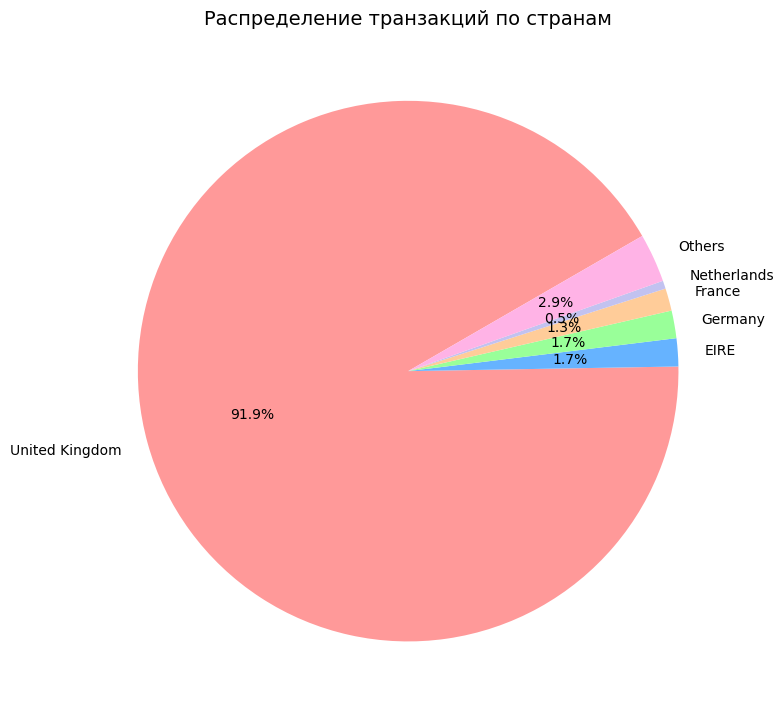

In [6]:
top5_countries = df['Country'].value_counts().head(5)
others_count = df['Country'].value_counts().iloc[5:].sum()
plot_data = pd.concat([top5_countries, pd.Series([others_count], index=['Others'])])

plt.figure(figsize=(8, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']
plt.pie(plot_data.values, labels=plot_data.index, autopct='%1.1f%%', colors=colors, startangle=30)
plt.title('Распределение транзакций по странам', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
print("\n" + "=" * 55)
print(f"{'Показатель':<20} {'Quantity':>15} {'Price (£)':>15}")
print("=" * 55)
print(f"{'Кол-во записей':<20} {df['Quantity'].count():>15,.0f} {df['Price'].count():>15,.0f}")
print(f"{'Ср. значение':<20} {df['Quantity'].mean():>15,.2f} {df['Price'].mean():>15,.2f}")
print(f"{'Станд. отклонение':<20} {df['Quantity'].std():>15,.2f} {df['Price'].std():>15,.2f}")
print(f"{'Min':<20} {df['Quantity'].min():>15,.0f} {df['Price'].min():>15,.2f}")
print(f"{'25%':<20} {df['Quantity'].quantile(0.25):>15,.0f} {df['Price'].quantile(0.25):>15,.2f}")
print(f"{'50% (медиана)':<20} {df['Quantity'].median():>15,.0f} {df['Price'].median():>15,.2f}")
print(f"{'75%':<20} {df['Quantity'].quantile(0.75):>15,.0f} {df['Price'].quantile(0.75):>15,.2f}")
print(f"{'Max':<20} {df['Quantity'].max():>15,.0f} {df['Price'].max():>15,.2f}")
print("=" * 55)


Показатель                  Quantity       Price (£)
Кол-во записей             1,067,371       1,067,371
Ср. значение                    9.94            4.65
Станд. отклонение             172.71          123.55
Min                          -80,995      -53,594.36
25%                                1            1.25
50% (медиана)                      3            2.10
75%                               10            4.15
Max                           80,995       38,970.00


#### Выводы по качеству данных

1. Отрицательные Quantity (min = −80 995) — возвраты. Неинформативны для кластеризации покупательского поведения.
2. Отрицательные Price (min = −53 594 £) — артефакты, цена не может быть отрицательной.
3. Экстремальные выбросы Quantity (max = +80 995) — оптовые заказы. Меняют масштаб кластеров и скрывают розничных клиентов.
4. Экстремальные выбросы Price (max = 38 970 £) — вероятно, ошибки или единичные уникальные товары (средняя цена всего £4.65).
5. Разрыв mean/median по Quantity (9.94 vs 3) — среднее в 3 раза выше медианы → присутствуют крупные оптовые заказы.
6. Разрыв mean/median по Price (£4.65 vs £2.10) — среднее в 2 раза выше медианы → есть дорогие позиции-выбросы.

Необходимо удалить отрицательные значения, отмены и ограничить выбросы верхними перцентилями.

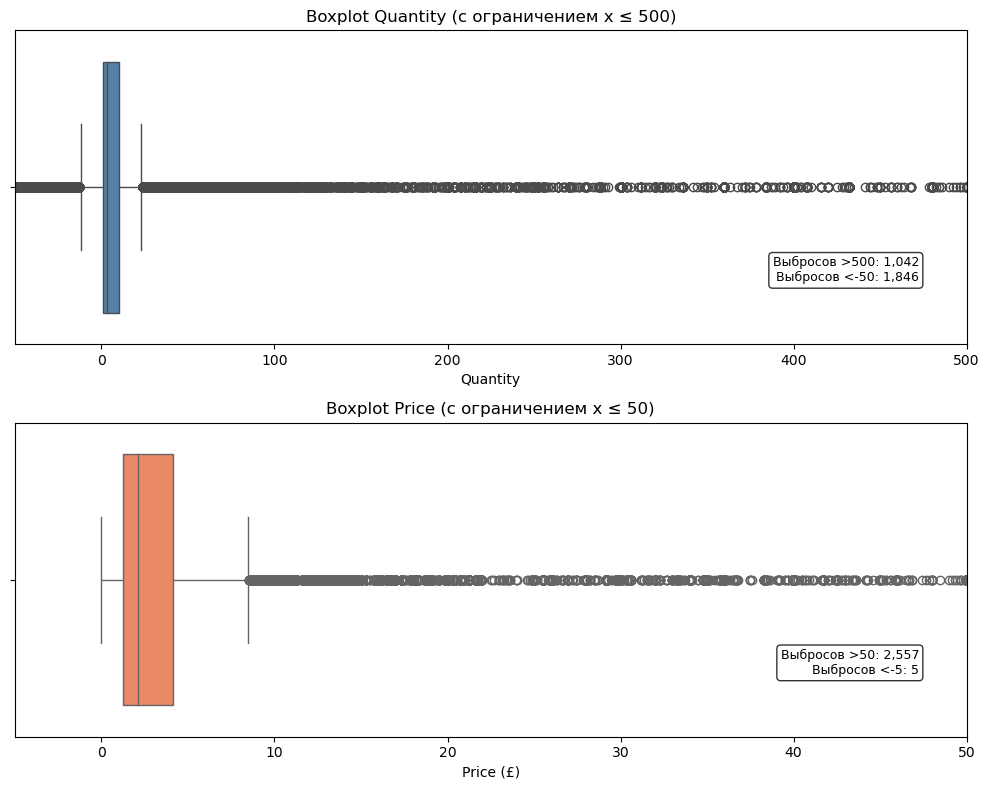

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

sns.boxplot(x=df['Quantity'], ax=axes[0], color='steelblue', orient='h')
axes[0].set_title('Boxplot Quantity (с ограничением x ≤ 500)', fontsize=12)
axes[0].set_xlabel('Quantity')
axes[0].set_xlim(-50, 500)

outliers_q_right = (df['Quantity'] > 500).sum()
outliers_q_left = (df['Quantity'] < -50).sum()
axes[0].text(0.95, 0.2, f'Выбросов >500: {outliers_q_right:,}\nВыбросов <-50: {outliers_q_left:,}', 
            transform=axes[0].transAxes, fontsize=9, ha='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

sns.boxplot(x=df['Price'], ax=axes[1], color='coral', orient='h')
axes[1].set_title('Boxplot Price (с ограничением x ≤ 50)', fontsize=12)
axes[1].set_xlabel('Price (£)')
axes[1].set_xlim(-5, 50)

outliers_p_right = (df['Price'] > 50).sum()
outliers_p_left = (df['Price'] < -5).sum()
axes[1].text(0.95, 0.2, f'Выбросов >50: {outliers_p_right:,}\nВыбросов <-5: {outliers_p_left:,}', 
            transform=axes[1].transAxes, fontsize=9, ha='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

#### Выводы по распределениям

1. Quantity (усечение −50 до +500 шт):
   Основная масса покупок — от 0 до 20 шт на транзакцию.
   Количество выбросов справа (>500) в несколько раз больше, чем слева (<−50) — это оптовые заказы.

2. Price (усечение −5 до +50 £):
   Значительное число выбросов справа указывает на небольшое количество очень дорогих товаров на фоне основной массы дешёвых позиций.

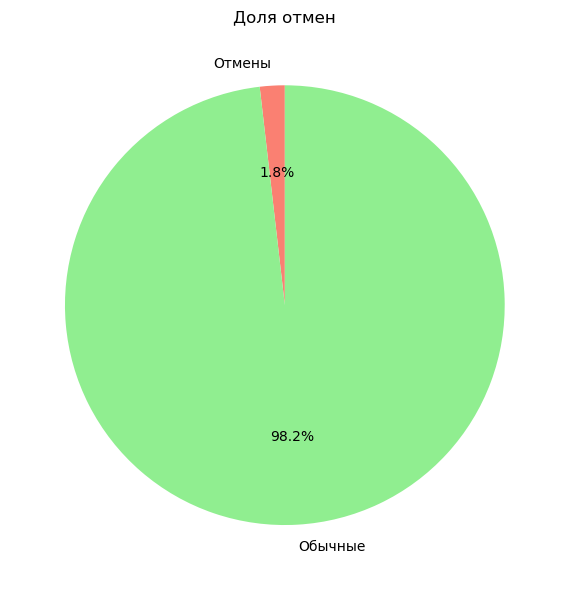

Количество отмен: 19494


In [9]:
# Отмены - Invoice начинается с 'C'
df['is_cancellation'] = df['Invoice'].astype(str).str.startswith('C', na=False)
cancellation_count = df['is_cancellation'].sum()
cancellation_pct = cancellation_count / len(df) * 100

plt.figure(figsize=(6, 6))
plt.pie([cancellation_count, len(df) - cancellation_count], 
        labels=['Отмены', 'Обычные'], 
        autopct='%1.1f%%', 
        colors=['salmon', 'lightgreen'],
        startangle=90)
plt.title(f'Доля отмен', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Количество отмен: {cancellation_count:}")

## 4. Подготовка данных

### Общий пайплайн очистки и инжиниринга:
- Удаление пропусков, дубликатов, отмен и отрицательных значений
- Преобразование типов
- Агрегация транзакций в клиентские профили (RFM)
- Ограничение выбросов 99-м перцентилем
- Отбор признаков
- Масштабирование StandardScaler

---

#### Удаление пропусков и дубликатов
Строки без Customer ID невозможно привязать к клиенту — удалены (~25%). Полные дубликаты также исключены.


In [10]:
df_clean = df.copy()

initial_rows = len(df_clean)
df_clean = df_clean.dropna(subset=['Customer ID']) # удал. строки с пустым Customer ID
print(f"Удалено строк с пропущенным Customer ID: {initial_rows - len(df_clean):,} ({100 - len(df_clean)/initial_rows*100:.1f}%)")

duplicates_count = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"Удалено полных дубликатов строк: {duplicates_count:,}")

Удалено строк с пропущенным Customer ID: 243,007 (22.8%)
Удалено полных дубликатов строк: 26,479


#### Обработка отмен и отрциательных значений

Транзакции с InvoiceNo на 'C' (отмены) и отрицательные Quantity/Price удалены.


In [11]:
# удал. отмены (Invoice начинается 'C')
cancellations_before = len(df_clean)
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C', na=False)] 
print(f"Удалено отмен: {cancellations_before - len(df_clean):,}")

rows_before = len(df_clean)
# удал. строки с отрицательными Quantity и Price
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)] 
print(f"Удалено отрицательных значений: {rows_before - len(df_clean):,}")

Удалено отмен: 18,390
Удалено отрицательных значений: 70


#### Преобразование типов
- Customer ID приведён к int для быстрой группировки. 
- InvoiceDate преобразован в datetime для расчёта Recency (давности покупки). 
- Добавлен TotalPrice = общая стоимость строки (Quantity × Price).

In [12]:
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

#### Агрегация по клиентам
Исходные строки — позиции в чеках. Для кластеризации данные сгруппированы по CustomerID в клиентские профили:
- Frequency — число уникальных транзакций
- Monetary — общая сумма покупок
- TotalQuantity — общее количество товаров
- Recency — дней с последней покупки
- UniqueProducts — количество уникальных товаров


In [13]:
max_date = df_clean['InvoiceDate'].max() # макс-я дата для расчета последней покупки

customer_df = df_clean.groupby('Customer ID').agg({
    'Invoice': 'nunique',                              # Frequency
    'TotalPrice': 'sum',                               # Monetary
    'Quantity': 'sum',                                 # TotalQuantity 
    'InvoiceDate': lambda x: (max_date - x.max()).days, # Recency
    'StockCode': 'nunique'                             # UniqueProducts
}).reset_index()

# Переименовываем колонки
customer_df.columns = ['CustomerID', 'Frequency', 'Monetary', 'TotalQuantity', 'Recency', 'UniqueProducts']

print(f"\nАгрегированная таблица: {customer_df.shape[0]} клиентов, {customer_df.shape[1]} признаков")
customer_df.head()


Агрегированная таблица: 5878 клиентов, 6 признаков


,CustomerID,Frequency,Monetary,TotalQuantity,Recency,UniqueProducts
0,12346,12,77556.46,74285,325,27
1,12347,8,4921.53,2967,1,126
2,12348,5,2019.40,2714,74,25
3,12349,4,4428.69,1624,18,138
4,12350,1,334.40,197,309,17


#### Ограничение выбросов
Оптовые клиенты создают экстремальные выбросы, искажающие кластеризацию. Monetary, TotalQuantity и Frequency ограничены сверху 99-м перцентилем.

In [14]:
for col in ['Monetary', 'TotalQuantity', 'Frequency']:
    cap = customer_df[col].quantile(0.99)
    before = len(customer_df[customer_df[col] > cap])
    customer_df[col] = customer_df[col].clip(upper=cap)
    print(f"{col}: ограничено {cap:.0f}, затронуто {before} записей")

print(f"\nПосле ограничения выбросов: {len(customer_df)} клиентов")

Monetary: ограничено 29206, затронуто 59 записей
TotalQuantity: ограничено 17090, затронуто 59 записей
Frequency: ограничено 46, затронуто 58 записей

После ограничения выбросов: 5878 клиентов


#### Отбор признаков
- Country исключён из-за сильного дисбаланса (92% UK). 
- StockCode и Description заменены на UniqueProducts - количество уникальных товаров, купленных клиентом. Один числовой признак вместо сотен категорий. 

Итоговый набор: Monetary, Frequency, Recency, TotalQuantity, UniqueProducts. Только числовые признаки.


#### Масштабирование
Признаки в разных единицах (фунты, штуки, дни) приведены к единому масштабу через StandardScaler, чтобы ни один признак не доминировал в расчёте расстояний.


In [15]:
features = ['Monetary', 'Frequency', 'Recency', 'TotalQuantity', 'UniqueProducts'] # признаки для кластеризации
X = customer_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # данные для кластеризации

print(f"Матрица признаков для кластеризации: {X_scaled.shape}, где:")
print(f"  кол-во клиентов: {X_scaled.shape[0]}")
print(f"  кол-во признаков: {X_scaled.shape[1]}")

print("Среднее каждого признака после масштабирования:", X_scaled.mean(axis=0).round(2))
print("Стандартное отклонение:", X_scaled.std(axis=0).round(2))

Матрица признаков для кластеризации: (5878, 5), где:
  кол-во клиентов: 5878
  кол-во признаков: 5
Среднее каждого признака после масштабирования: [ 0. -0. -0.  0.  0.]
Стандартное отклонение: [1. 1. 1. 1. 1.]


## 5. Построение кластеризации

### Общий подход:
- Выбраны 2 алгоритма: K-Means и Agglomerative Clustering
- Оптимальное число кластеров подобрано методом локтя и силуэтным анализом (k = 2–10)
- Визуализация через PCA (2 компоненты)

---

#### Выбор алгоритмов

- **K-Means** — разбивает данные на k кластеров, минимизируя расстояние от точек до центров кластеров. Быстрый, хорошо масштабируется, но предполагает сферическую форму кластеров.
- **Agglomerative Clustering** — иерархический метод: начинает с каждой точки как отдельного кластера и последовательно объединяет ближайшие. Показывает структуру вложенности, не требует задавать число кластеров заранее.

#### Определение оптимального числа кластеров

Перебор k от 2 до 10 с оценкой двумя метриками:

- **Метод локтя (Elbow Method)** — по графику инерции ищется точка, после которой снижение замедляется.
- **Силуэт (Silhouette Score)** — измеряет компактность и разделимость кластеров (от −1 до 1). Выбирается k, при котором силуэт максимален.


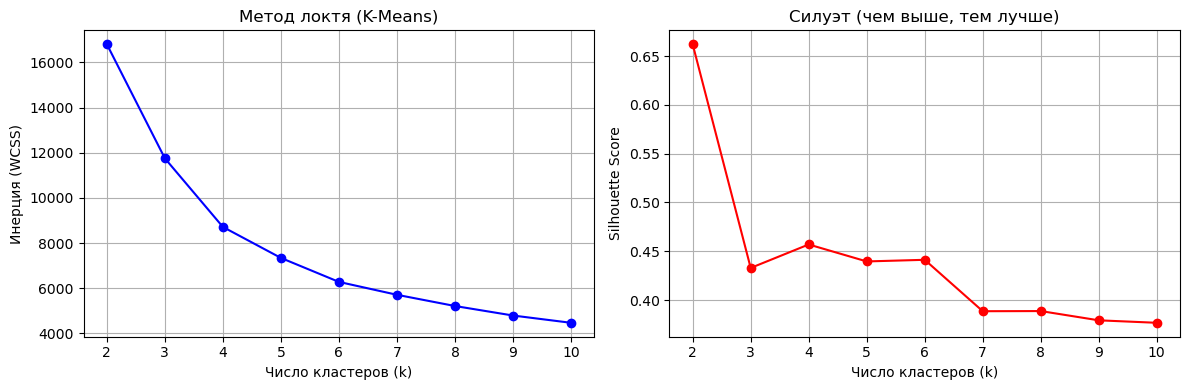

Лучшее число кластеров по силуэту: k = 2


In [16]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_) # Метод локтя
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_)) # Силуэт

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Число кластеров (k)')
axes[0].set_ylabel('Инерция (WCSS)')
axes[0].set_title('Метод локтя (K-Means)')
axes[0].grid(True)

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Число кластеров (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Силуэт (чем выше, тем лучше)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Лучшее число кластеров по силуэту: k = {best_k}")

In [17]:
# Обучение K-Means с выбранным k
k_means = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = k_means.fit_predict(X_scaled)

print(f"K-Means: {best_k} кластеров")
print(f"Распределение: {pd.Series(kmeans_labels).value_counts().sort_index().tolist()}")

K-Means: 2 кластеров
Распределение: [508, 5370]


In [18]:
# Обучение иерархической (Agglomerative) кластеризации 
# Используем то же лучшее k из предыдущего шага
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

print(f"Agglomerative Clustering: {best_k} кластеров")
print(f"Распределение: {pd.Series(agg_labels).value_counts().sort_index().tolist()}")

Agglomerative Clustering: 2 кластеров
Распределение: [5359, 519]


#### Визуализация и сравнение методов

Для визуализации 5-мерного пространства признаков (Monetary, Frequency, Recency, TotalQuantity, UniqueProducts) применён PCA (2 компоненты). PCA - метод снижения размерности, который находит оси (главные компоненты) в направлении максимального разброса данных: первая ось — вдоль наибольшей дисперсии, вторая — перпендикулярно ей. Проекция на плоскость неизбежно теряет часть информации, но позволяет увидеть структуру кластеров.


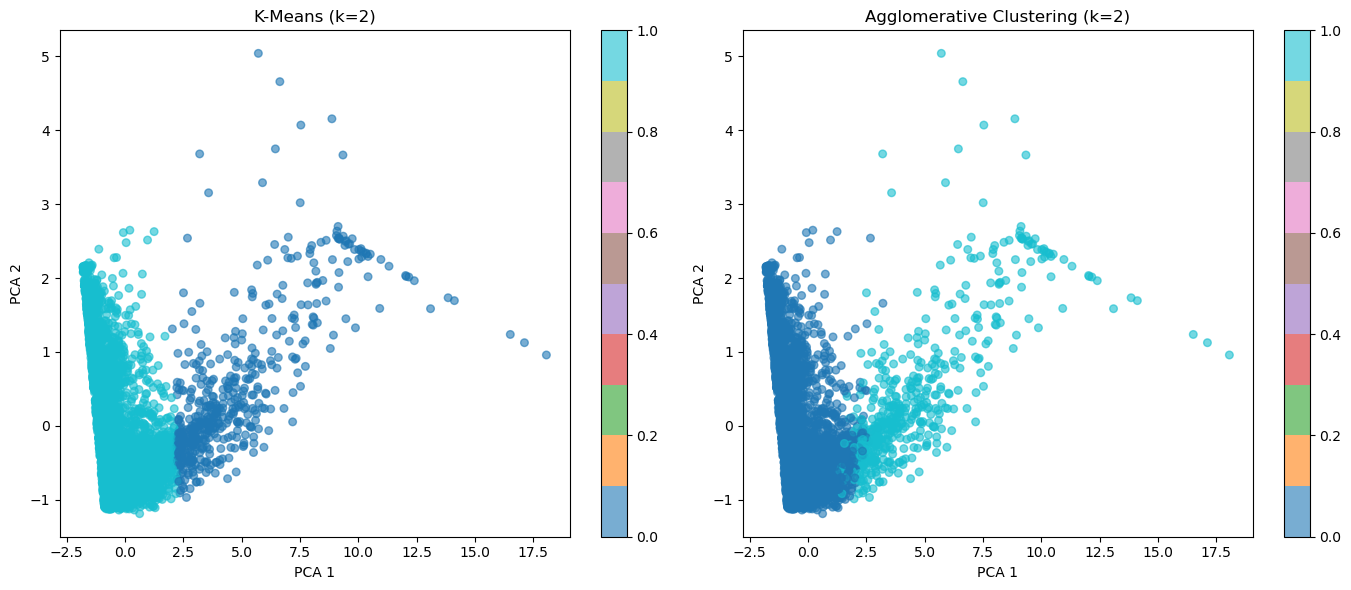

In [19]:
pca = PCA(n_components=2, random_state=42) # снижаем размерность до 2 компонент
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=30)
axes[0].set_title(f'K-Means (k={best_k})')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='tab10', alpha=0.6, s=30)
axes[1].set_title(f'Agglomerative Clustering (k={best_k})')
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

#### Выводы по визуализации
Оба метода (K-Means и Agglomerative Clustering) выделили одинаковые группы: слева — плотный компактный кластер (клиенты со схожим поведением), справа — более разреженный кластер с меньшим числом точек и бóльшим разбросом.

Вывод: данные устойчиво разбиваются на 2 интерпретируемых сегмента - 2 типа клиентов.


## 6. Оценка качества кластеризации

Качество оценивалось тремя метриками:

| Метрика | Что измеряет | Правило |
|---|---|---|
| Silhouette Score | Компактность + разделимость кластеров | Выше = лучше (max = 1) |
| Calinski-Harabasz Index | Отношение межкластерной дисперсии к внутрикластерной | Выше = лучше |
| Davies-Bouldin Index | Среднее «сходство» кластера с ближайшим соседом | Ниже = лучше (min = 0) |



Сравнение метрик качества
         name  silhouette  calinski_harabasz  davies_bouldin
      K-Means      0.6622          4400.7493          0.8448
Agglomerative      0.6556          4281.1986          0.8595



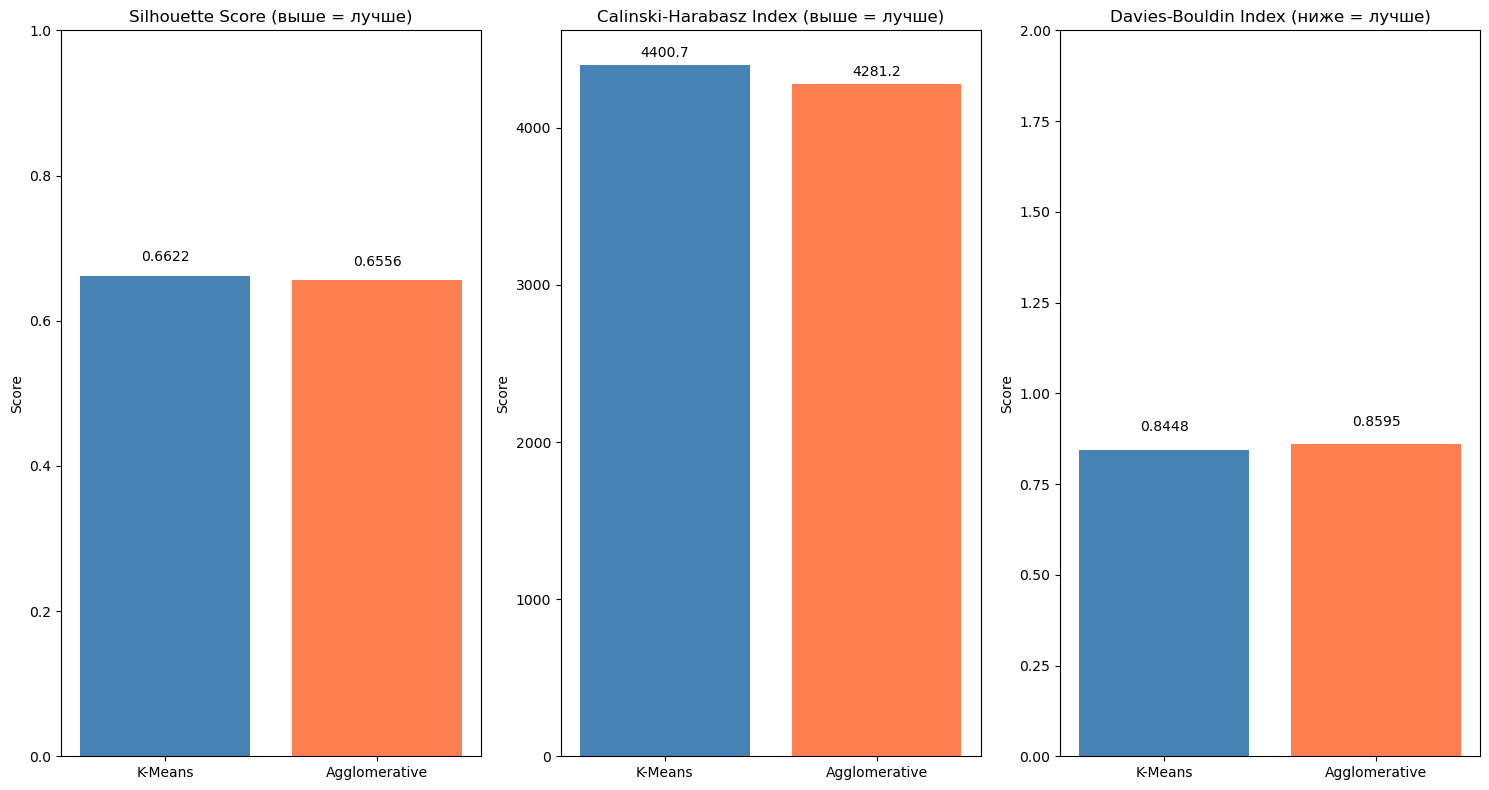

In [20]:
# Метрики качества кластеризации
def evaluate_clustering(labels, data, name):
    sil = silhouette_score(data, labels)
    ch = calinski_harabasz_score(data, labels)
    db = davies_bouldin_score(data, labels)
    return {'name': name, 'silhouette': sil, 'calinski_harabasz': ch, 'davies_bouldin': db}

kmeans_metrics = evaluate_clustering(kmeans_labels, X_scaled, "K-Means") # оценка K-Means
agg_metrics = evaluate_clustering(agg_labels, X_scaled, "Agglomerative") # оценка Agglomerative

results = pd.DataFrame([
    kmeans_metrics,
    agg_metrics
])

print("\n" + "="*60)
print("Сравнение метрик качества")
print("="*60)
print(results[['name', 'silhouette', 'calinski_harabasz', 'davies_bouldin']].round(4).to_string(index=False))
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 8))

# Данные
methods = results['name'].tolist()
sil_scores = results['silhouette'].tolist()
ch_scores = results['calinski_harabasz'].tolist()
db_scores = results['davies_bouldin'].tolist()

bars1 = axes[0].bar(methods, sil_scores, color=['steelblue', 'coral'])
axes[0].set_title('Silhouette Score (выше = лучше)', fontsize=12)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars1, sil_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{val:.4f}', ha='center', fontsize=10)

bars2 = axes[1].bar(methods, ch_scores, color=['steelblue', 'coral'])
axes[1].set_title('Calinski-Harabasz Index (выше = лучше)', fontsize=12)
axes[1].set_ylabel('Score')
for bar, val in zip(bars2, ch_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                f'{val:.1f}', ha='center', fontsize=10)

bars3 = axes[2].bar(methods, db_scores, color=['steelblue', 'coral'])
axes[2].set_title('Davies-Bouldin Index (ниже = лучше)', fontsize=12)
axes[2].set_ylabel('Score')
axes[2].set_ylim(0, 2)
for bar, val in zip(bars3, db_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                f'{val:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

#### Выводы по качеству кластеризации
1. Оба алгоритма показали хорошее качество и выделили одинаковую структуру данных, что говорит об устойчивости найденных кластеров. Silhouette Score ~0.66 означает, что кластеры четко отделены друг от друга (значение выше 0.5 считается хорошим, выше 0.7 — отличным).
2. K-Means немного лучше Agglomerative по всем трем метрикам. Разница небольшая, но устойчивая.
 
Для практического использования выбран K-Means как более быстрый и интерпретируемый.

## 7. Интерпретация кластеров

#### Сравнение кластеров по средним значениям

Для каждого кластера рассчитаны средние значения RFM-признаков. Построена тепловая карта (нормализация в % от максимума по каждому признаку). Нормализованные профили показывают, по каким параметрам кластер «сильный» (~100%), а по каким — «слабый» (~0%).


In [21]:
# Добавляем метки кластеров в таблицу с исходными признаками
customer_df['Cluster_KMeans'] = kmeans_labels
customer_df['Cluster_Agg'] = agg_labels

cluster_profiles = customer_df.groupby('Cluster_KMeans')[['Monetary', 'Frequency', 'Recency', 'TotalQuantity', 'UniqueProducts']].mean()
print("Средние значения по кластерам:")
print(cluster_profiles.round(2))

Средние значения по кластерам:
                Monetary  Frequency  Recency  TotalQuantity  UniqueProducts
Cluster_KMeans                                                             
0               13054.38      24.63    37.37        7510.52          295.70
1                1287.34       4.00   215.75         746.35           61.77


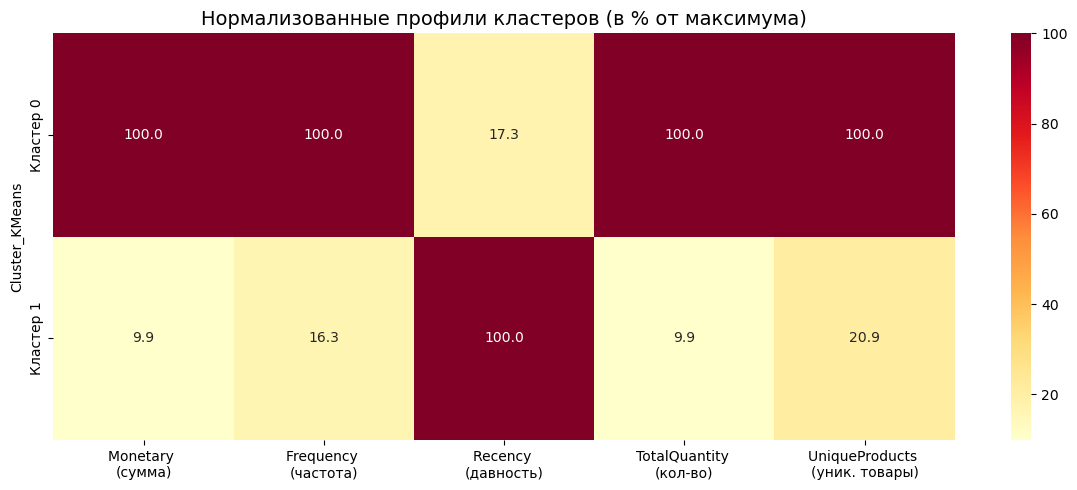

In [22]:
cluster_profiles_norm = cluster_profiles.div(cluster_profiles.max()) * 100

# print("\nНормализованные профили кластеров (% от максимума):")
# print(cluster_profiles_norm.round(1))

fig, ax = plt.subplots(figsize=(12, 5))
# Тепловая карта
sns.heatmap(cluster_profiles_norm, annot=True, fmt='.1f', cmap='YlOrRd', 
            xticklabels=['Monetary \n(сумма)', 'Frequency \n(частота)', 'Recency \n(давность)', 
                        'TotalQuantity \n(кол-во)', 'UniqueProducts \n(уник. товары)'],
            yticklabels=[f'Кластер {i}' for i in cluster_profiles_norm.index],
            ax=ax)
ax.set_title('Нормализованные профили кластеров (в % от максимума)', fontsize=14)

ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center') # подписи столбцов горизонтально

plt.tight_layout()
plt.show()

#### Интерпретация кластеров

**Кластер 0 — VIP-клиенты (8.6%)**  
Максимальные значения по всем метрикам: тратят много, покупают часто, берут товаров много и разнообразно, последняя покупка недавняя (17%). Это лояльное ядро клиентской базы — оптовики и постоянные покупатели. Основной источник выручки.

**Кластер 1 — Уходящие клиенты (91.4%)**  
Минимальная активность по всем метрикам: низкие траты (9.9%), покупают редко, берут мало товаров, последняя покупка была давно. Основная масса клиентов, которая почти потеряна. Без вмешательства перейдут в отток.

#### Характеристика кластеров
Для каждого кластера определен портрет среднестатистического клиента.

In [23]:
# Данные из переменных
size_cluster0 = len(customer_df[customer_df['Cluster_KMeans'] == 0])
pct_cluster0 = size_cluster0 / len(customer_df) * 100
size_cluster1 = len(customer_df[customer_df['Cluster_KMeans'] == 1])
pct_cluster1 = size_cluster1 / len(customer_df) * 100

# Получаем средние значения
avg_monetary_0 = cluster_profiles.loc[0, 'Monetary']
avg_freq_0 = cluster_profiles.loc[0, 'Frequency']
avg_recency_0 = cluster_profiles.loc[0, 'Recency']
avg_quantity_0 = cluster_profiles.loc[0, 'TotalQuantity']
avg_products_0 = cluster_profiles.loc[0, 'UniqueProducts']

avg_monetary_1 = cluster_profiles.loc[1, 'Monetary']
avg_freq_1 = cluster_profiles.loc[1, 'Frequency']
avg_recency_1 = cluster_profiles.loc[1, 'Recency']
avg_quantity_1 = cluster_profiles.loc[1, 'TotalQuantity']
avg_products_1 = cluster_profiles.loc[1, 'UniqueProducts']

# Рассчитываем нужную ширину под максимальную длину текста
col_width = 25
param_width = 45
# Форматируем заголовки с размером кластера
header0 = f'КЛАСТЕР 0'
header0_sub = f'{size_cluster0} клиентов ({pct_cluster0:.1f}%)'
header1 = f'КЛАСТЕР 1'
header1_sub = f'{size_cluster1} клиентов ({pct_cluster1:.1f}%)'

print("=" * (param_width + col_width * 2 + 5))
print(f"{'Параметр':<{param_width}}  {header0:>{col_width}} {header1:>{col_width}}")
print(f"{'':<{param_width}}  {'VIP-клиенты':>{col_width}} {'Уходящие клиенты':>{col_width}}")
print(f"{'':<{param_width}}  {header0_sub:>{col_width}} {header1_sub:>{col_width}}")
print("=" * (param_width + col_width * 2 + 5))
print(f"{'💰 Средняя сумма покупок (£)':<{param_width}} {f'{avg_monetary_0:.0f}':>{col_width}} {f'{avg_monetary_1:.0f}':>{col_width}}")
print(f"{'🔄 Среднее число транзакций':<{param_width}} {f'{avg_freq_0:.0f}':>{col_width}} {f'{avg_freq_1:.0f}':>{col_width}}")
print(f"{'📅 Средняя давность (дней с последней покупки)':<{param_width}} {f'{avg_recency_0:.0f}':>{col_width}} {f'{avg_recency_1:.0f}':>{col_width}}")
print(f"{'📦 Среднее количество товаров':<{param_width}} {f'{avg_quantity_0:.0f}':>{col_width}} {f'{avg_quantity_1:.0f}':>{col_width}}")
print(f"{'🏷️ Среднее число уникальных товаров':<{param_width}}  {f'{avg_products_0:.0f}':>{col_width}} {f'{avg_products_1:.0f}':>{col_width}}")
print("=" * (param_width + col_width * 2 + 5))

Параметр                                                       КЛАСТЕР 0                 КЛАСТЕР 1
                                                             VIP-клиенты          Уходящие клиенты
                                                     508 клиентов (8.6%)     5370 клиентов (91.4%)
💰 Средняя сумма покупок (£)                                       13054                      1287
🔄 Среднее число транзакций                                           25                         4
📅 Средняя давность (дней с последней покупки)                        37                       216
📦 Среднее количество товаров                                       7511                       746
🏷️ Среднее число уникальных товаров                                  296                        62


## 8. Выводы и практическая значимость

### Бизнес-вывод
Кластеризация выявила сильный дисбаланс: ~9% клиентов (VIP) обеспечивают основную выручку, а ~91% — «спящая» аудитория. Это типичная картина для e-commerce без программы удержания. Выделено 2 чётких сегмента, благодаря чему бизнес получает возможность точечно работать с каждой группой вместо массовых рассылок.

### Рекомендации

**Для VIP-клиентов (Кластер 0, 8.6%):**
- Программа лояльности с накопительными скидками
- Персональный менеджер для оптовых заказов
- Ранний доступ к новым коллекциям и эксклюзивные предложения
- Цель: удержание и рост среднего чека

**Для уходящих клиентов (Кластер 1, 91.4%):**
- Рассылка с персональной скидкой 10–15% на следующий заказ
- Email/смс «Мы давно Вас не видели»
- Бесплатная доставка при заказе от пороговой суммы
- Цель: вернуть хотя бы 5–10% сегмента

### Ограничения исследования

- Данные одного магазина и периода 2009–2011 — результаты не универсальны, но методология переносима.
- ~25% данных потеряно из-за пропусков CustomerID.
- Отсутствие демографии ограничивает глубину сегментации.
- Выделено только 2 кластера — возможно, более тонкая настройка выявит дополнительные сегменты.

### Возможные улучшения

- Привлечь демографические данные (возраст, регион, способ оплаты).
- Протестировать другие алгоритмы: Gaussian Mixture, DBSCAN, OPTICS.
- Проверить разбиение на большее число кластеров (3-4).
- Сравнить с классической ручной RFM-сегментацией (без ML).
- Применить t-SNE/UMAP для более качественной визуализации (PCA теряет часть дисперсии).
- Провести анализ в динамике по месяцам/годам.
- Построить модель прогнозирования оттока на основе полученных признаков.
